In [66]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from   IPython.display import display, Markdown

columns = [
    "variance",
    "skewness",
    "curtosis",
    "entropy",
    "class"
]

data = pd.read_csv(
    "../data/data_banknote_authentication.txt",
    header = None,
    names  = columns
)


In [67]:
data.shape

print(f"The dataset has {data.shape[0]} rows and {data.shape[1]} features")

The dataset has 1372 rows and 5 features


In [68]:
data.head()

,variance,skewness,curtosis,entropy,class
0,3.62160,8.6661,-2.8073,-0.44699,0
1,4.54590,8.1674,-2.4586,-1.46210,0
2,3.86600,-2.6383,1.9242,0.10645,0
3,3.45660,9.5228,-4.0112,-3.59440,0
4,0.32924,-4.4552,4.5718,-0.98880,0


In [69]:
data.describe()

,variance,skewness,curtosis,entropy,class
count,1372.000000,1372.000000,1372.000000,1372.000000,1372.000000
mean,0.433735,1.922353,1.397627,-1.191657,0.444606
std,2.842763,5.869047,4.310030,2.101013,0.497103
min,-7.042100,-13.773100,-5.286100,-8.548200,0.000000
25%,-1.773000,-1.708200,-1.574975,-2.413450,0.000000
50%,0.496180,2.319650,0.616630,-0.586650,0.000000
75%,2.821475,6.814625,3.179250,0.394810,1.000000
max,6.824800,12.951600,17.927400,2.449500,1.000000


1. As we can see from the results here we can say that the data is not scaled so we need to do that for our KNN algorithm
 


In [70]:
data.tail()


,variance,skewness,curtosis,entropy,class
1367,0.40614,1.34920,-1.4501,-0.55949,1
1368,-1.38870,-4.87730,6.4774,0.34179,1
1369,-3.75030,-13.45860,17.5932,-2.77710,1
1370,-3.56370,-8.38270,12.3930,-1.28230,1
1371,-2.54190,-0.65804,2.6842,1.19520,1


In [71]:
data.isna().sum()

variance    0
skewness    0
curtosis    0
entropy     0
class       0
dtype: int64

In [72]:
data.columns.to_list()

['variance', 'skewness', 'curtosis', 'entropy', 'class']

In [73]:
data.mean()

variance    0.433735
skewness    1.922353
curtosis    1.397627
entropy    -1.191657
class       0.444606
dtype: float64

In [74]:
data.std()


variance    2.842763
skewness    5.869047
curtosis    4.310030
entropy     2.101013
class       0.497103
dtype: float64

In [75]:
data.duplicated().sum()
#As we can see here there are 24 duplicate rows

np.int64(24)

In [76]:
data = data.drop_duplicates(keep='first')

In [77]:
##Let's do some EDA to investigate the relationship between the features
data["class"].value_counts(normalize=True)
#The target is well-balanced 

class
0    0.547478
1    0.452522
Name: proportion, dtype: float64

## Exploratory Data Analysis (EDA)

## Feature Distributions

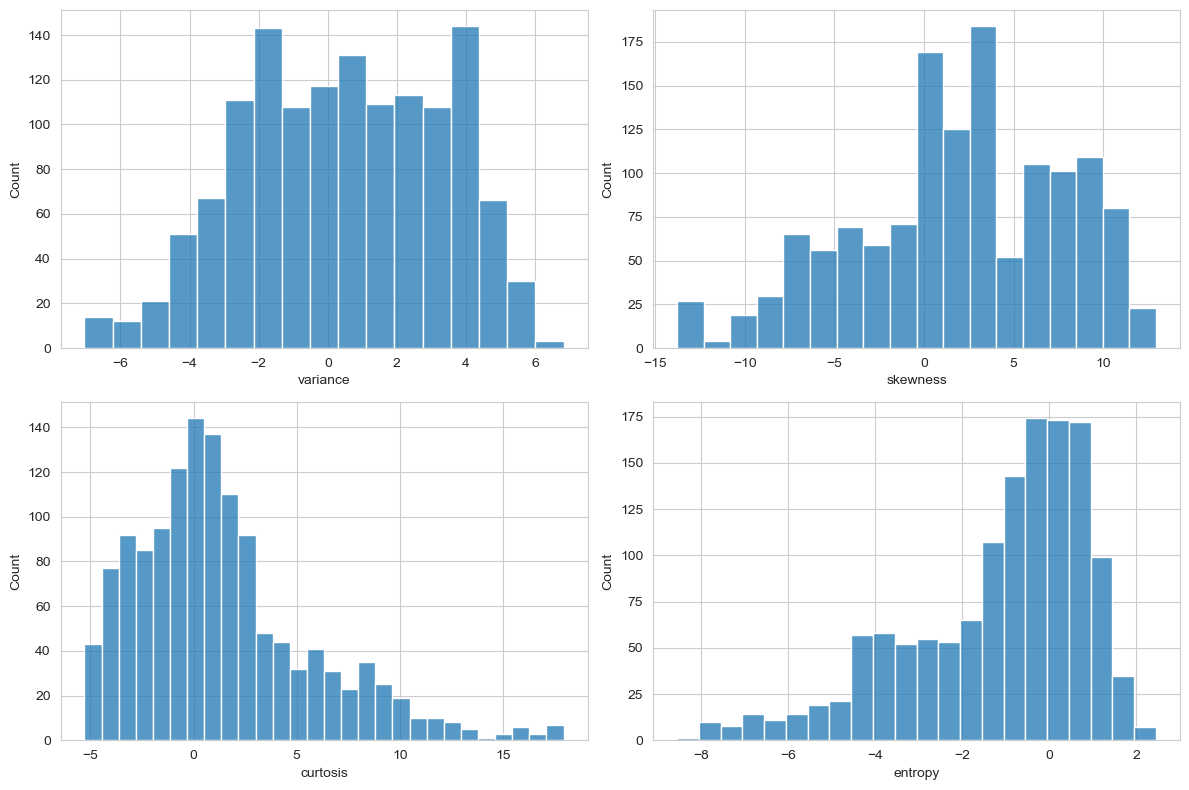

In [78]:
display(Markdown("## Feature Distributions"))

fig , axes = plt.subplots(2,2 , figsize=(12 , 8))
sns.histplot(data = data , x = "variance", ax = axes[0,0])
sns.histplot(data = data , x = "skewness", ax = axes[0,1])
sns.histplot(data = data , x = "curtosis", ax = axes[1,0])
sns.histplot(data = data , x = "entropy" , ax = axes[1,1])

plt.tight_layout()

fig.savefig(
    "../images/feature_distributions.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()



Doing a hist plot of the features shows that some features are skewed and will need to be investigated further for outliers , variance and skewness seem to follow a seemingly normal distribution.
Courtosis is right-skewed while entropy is left-skewed , will need to be investigated further with a boxplot.

## Feature Relationships

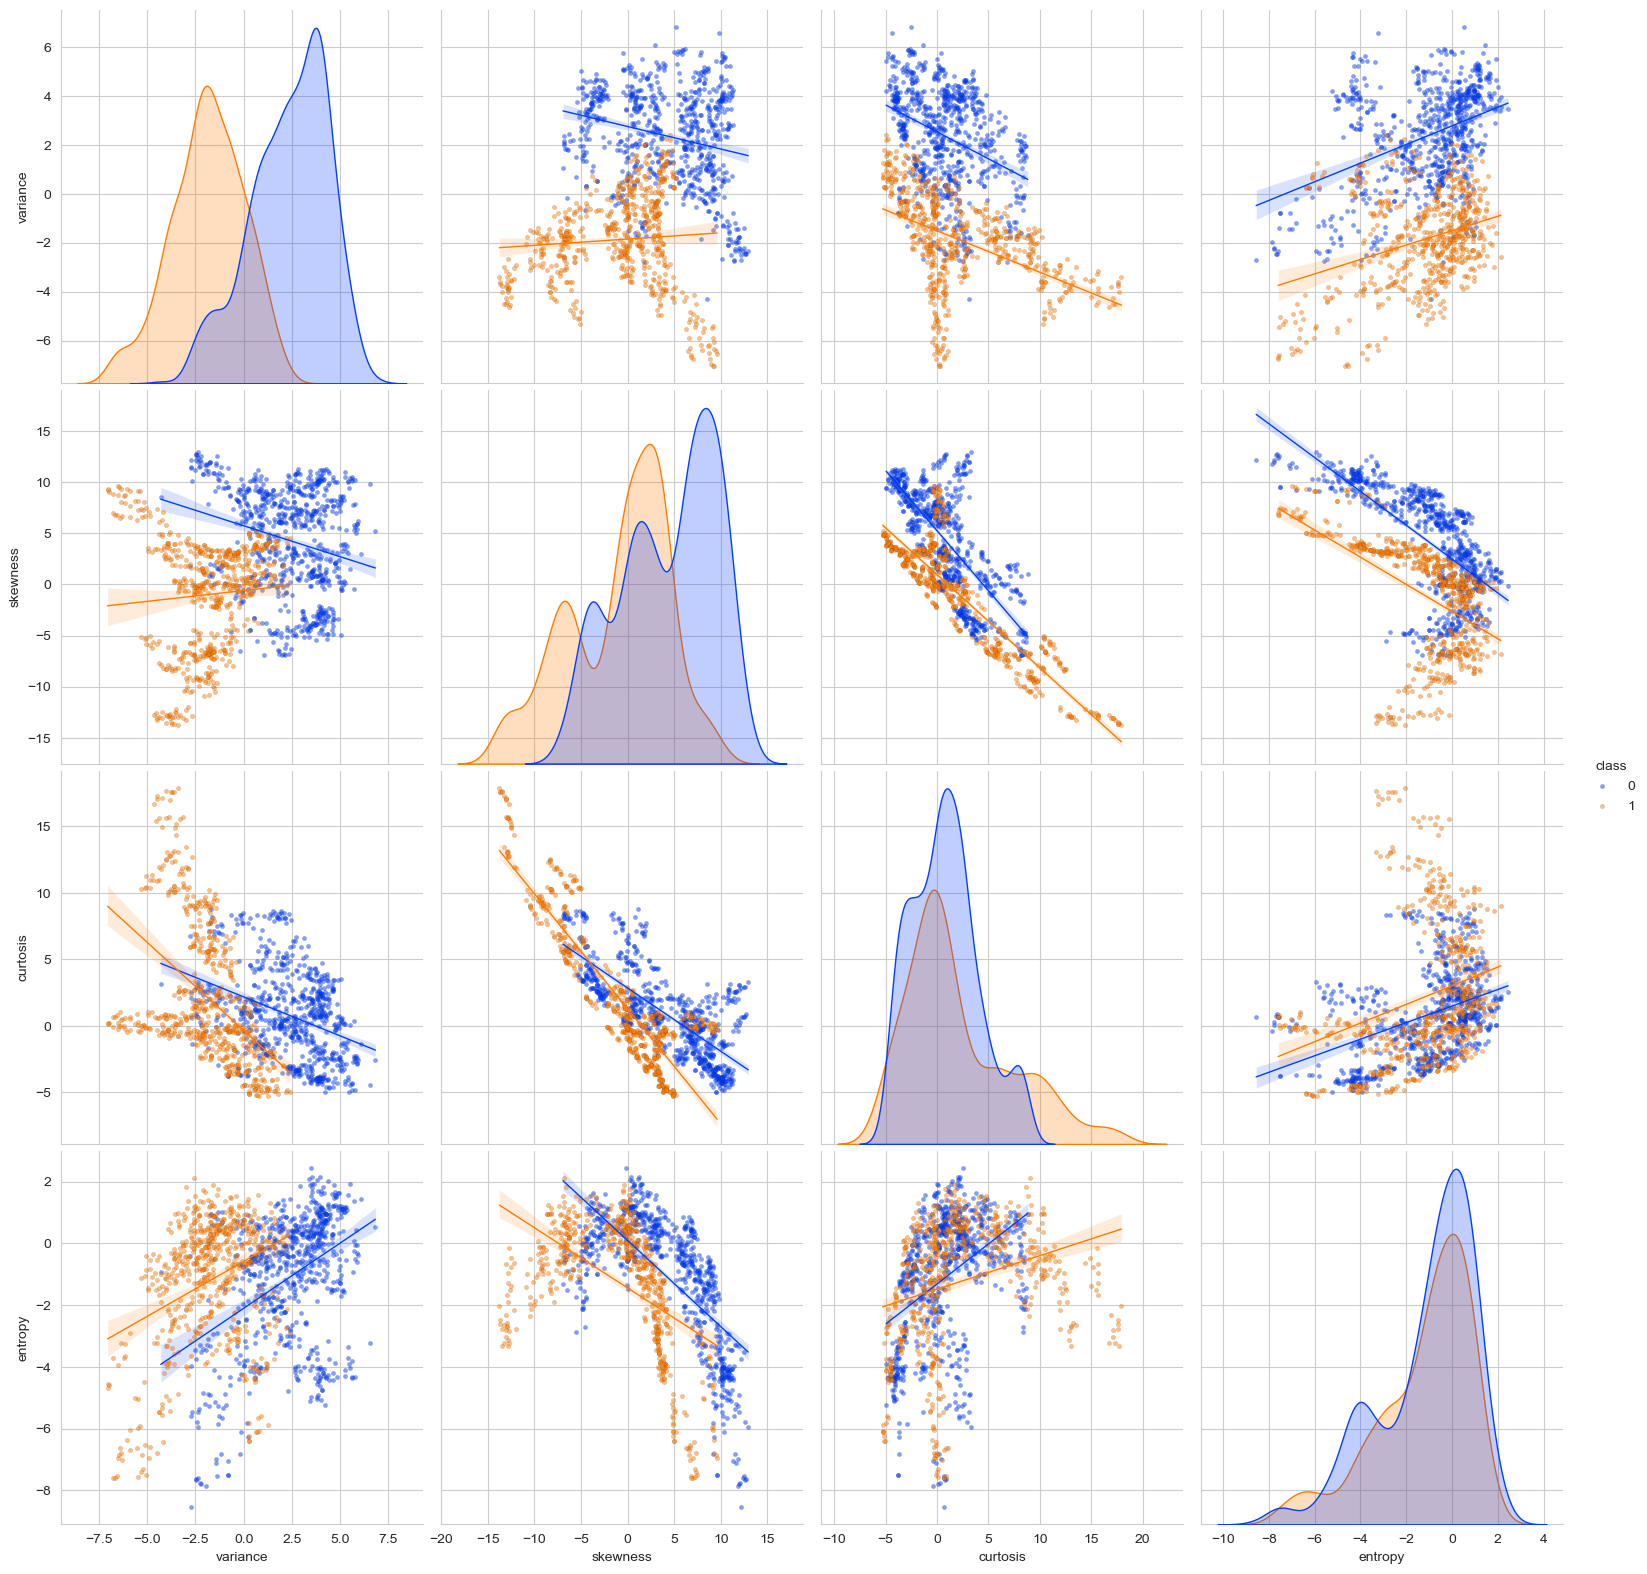

In [139]:
display(Markdown("## Feature Relationships"))
sns.set_style("whitegrid")
pairwiseplot =  sns.pairplot(
    data = data,
    vars =data.columns.drop("class"),
    hue = "class",
    kind = "reg",
    palette="bright",
    plot_kws = {
        "scatter_kws":{
            "alpha" : 0.5 ,
            "s":10,
            "edgecolor":"black",
            "linewidths":0.1
            },
        "line_kws" :{
            "linewidth":1
            }
        },
    height = 4,
    #diag_kind = "hist",
    #diag_kws = {"bins":30},

)

pairwiseplot.savefig(
    "../images/pair_plot_hist.png",
    dpi = 300,
    bbox_inches="tight"
)
plt.show()



Seeing this pairplot reveals something interesting , it seems like some of the scatterplots are kind of the same , they even follow the same direction and of the line and have almost the same patern of scatter . 
These shows on the correlation matrix below , with some features being highly correlated which might impact our KNN model.

# Correlation Matrix

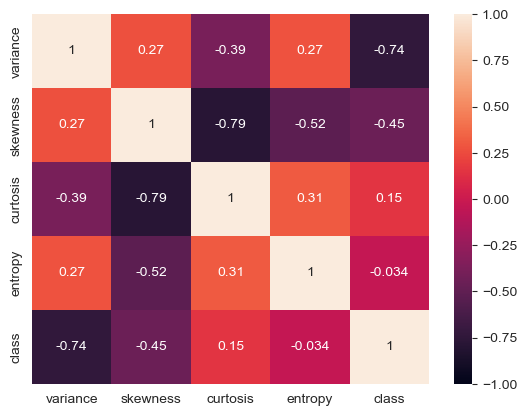

In [ ]:
display(Markdown("# Correlation Matrix"))
exc = data.data 
_ = sns.heatmap(
    data.corr(),
    vmin = -1,
    vmax = 1,
    annot = True
    )
plt.show()

# Outlier Exploration

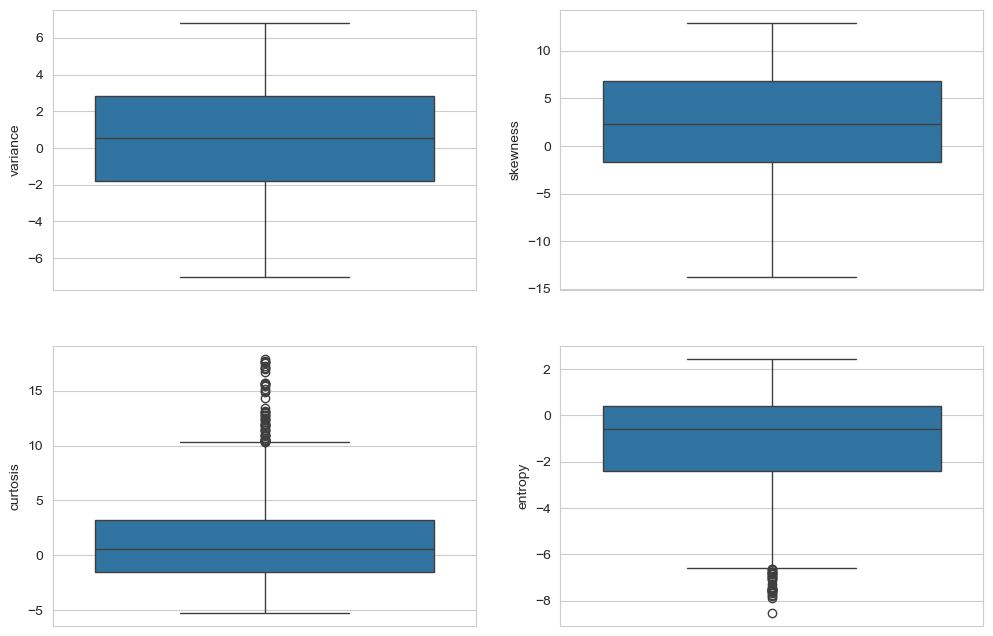

In [83]:
display(Markdown("# Outlier Exploration"))

fig1 , axes  = plt.subplots( 2, 2 ,figsize = (12,8))
sns.boxplot(data = data , y = "variance",ax = axes[0,0])
sns.boxplot(data = data , y = "skewness",ax = axes[0,1])
sns.boxplot(data = data , y = "curtosis",ax = axes[1,0])
sns.boxplot(data = data , y = "entropy" ,ax = axes[1,1])

fig1.savefig(
    "../images/possible_outliers.png",
    dpi = 300,
    bbox_inches = "tight"
)

plt.show()


As we can see from the boxplot there seems to be some outliers in the "Courtosis" and "entropy" columns. 

In [123]:
x = data["curtosis"]

Q1 = x.quantile(0.25)
Q3 = x.quantile(0.75)
IQR = Q3 - Q1

mask = (
    (x < Q1 - 1.5 * IQR) |
    (x > Q3 + 1.5 * IQR)
)

data.loc[mask, "class"].value_counts()

class
1    59
Name: count, dtype: int64

It is really interesting to see that all the curosis outliers are forged banknotes, so this is not necesseraly caused by errors in the data.
Lets also check the entropy column if we can find something similar.

In [127]:
z = data["entropy"]
Q1 =  z.quantile(0.25)
Q3 =  z.quantile(0.75)
IQR = Q3 - Q1 

mask = (
    (z < Q1 - IQR * 1.5 ) |
    (z > Q3 + IQR * 1.5 )
)

data.loc[mask , "class"].value_counts()

class
1    17
0    15
Name: count, dtype: int64

As we can see from these results we cant really build a hypothesis from these findings like we did with the other feature "curtosis"